# CV Peak Ratio Analysis — BioLogic
Reads `.mpr` files via `galvani`. All functions live in `cv_peakratio_biologic.py` — edit logic there, not here.
Adapted functions written by Rokas G. (automated calculation of rate constant)

## ── 1. IMPORTS ───────────────────────────────────────────────────────────

In [2]:
import os
import pandas as pd
from IPython.display import display
from cv_peakratio_biologic import (
    findSubdirNames, findMPRs, extractMPRs, makeOutDir,
    plotCVs, plotPeakCheck,
    exportPeakExcel, regressionPlot
)
%matplotlib inline


ModuleNotFoundError: No module named 'matplotlib.pyplot'

## ── 2. CONFIGURATION  ←  change things here ──────────────────────────────

In [ ]:
import glob
import re

def find_nequiv(folder_path):
    """Find nequiv from Excel filename like '10 eq.xlsx', '50 eq.xlsx' in the folder."""
    matches = glob.glob(os.path.join(folder_path, '*eq.xlsx'))
    if not matches:
        print(f'  WARN  no *eq.xlsx found in {folder_path}, using default nequiv={nequiv}')
        return nequiv   # fall back to config value
    # take the first match if multiple
    fname = os.path.basename(matches[0])
    m = re.search(r'(\d+)\s*eq', fname)
    if m:
        found = int(m.group(1))
        print(f'  nequiv={found} (from {fname})')
        return found
    print(f'  WARN  could not parse nequiv from {fname}, using default nequiv={nequiv}')
    return nequiv

In [ ]:
# ── Paths ──────────────────────────────────────────────────────────────────
rootPath       = r"./../../PZ-1-21\simple"   # <-- root folder

# Priority: runWholeRoot > multiNames > fileFolderName
runWholeRoot   = False          # True = process every subfolder in rootPath
multiNames     = []             # e.g. ['sub-1', 'sub-2'] to process specific subfolders
fileFolderName = "50eq-ArI4"      # single subfolder name if not using the above

replacers = {
    "_C01_filter": "",   # must come BEFORE "_C01" — order matters!
    "_C01_2":      "",
    "_C01":        "",
    " mVs":        "",
    "_2":          "",   # e.g. 100 mVs_2_C01 → handled by above, but just in case
    "5eq-":        "",
    "10eq-":       "",
    "40eq-":       "",
    "50eq-":       "",
}

# ── Peak search ranges (Volts) ──────────────────────────────────────────────
# Set to [] to search the entire segment
FpeakRange = []   # forward (reduction) peak search window, e.g. [-0.95, -0.75]
RpeakRange = []   # reverse (oxidation) peak search window

# ── Experiment settings ─────────────────────────────────────────────────────
nequiv       = 50     # substrate equivalents
goTexas      = True     # True = invert x-axis (Texas convention)
refElectrode = 'SCE'    # reference electrode label
cUnits       = 'mA'     # current units: 'mA' or 'uA'
noiseFactor  = 10       # smoothing level; higher = more filtering
drawRanges   = True     # True = shade peak search ranges on the peak-check plot

# ── Which cycle to plot and regress ─────────────────────────────────────────
cycle_to_plot  = 2      # 1-indexed; used for plots and regression

# ── Output settings ─────────────────────────────────────────────────────────
save_plot      = True
ligname        = ''
substrate_name = ''


## ── 3. LOAD FILES AND PLOT ────────────────────────────────────────────────────────

In [ ]:
import glob
import matplotlib.pyplot as plt
cmap = plt.get_cmap('viridis')   # still works
if runWholeRoot:
    multiNames = findSubdirNames(rootPath)
if not multiNames:
    multiNames = [fileFolderName]

for fileFolderName in multiNames:
    fileFolderPath = os.path.join(rootPath, fileFolderName)
    
    nequiv_folder = find_nequiv(fileFolderPath)

    # ── replace findMPRs with glob ─────────────────────────────
    MPRfileNames = [
        os.path.basename(f) for f in glob.glob(os.path.join(fileFolderPath, '*.mpr'))
        if '_filter' not in f and 'w_o_subs' not in f
    ]
    print(f'Files to load: {MPRfileNames}')
    # ──────────────────────────────────────────────────────────

    if not MPRfileNames:
        print(f"Skipping {fileFolderName} — no valid MPR files found")
        continue


    runs   = extractMPRs(MPRfileNames, fileFolderPath, replacers,
                         cUnits, noiseFactor, FpeakRange, RpeakRange)
    outDir = makeOutDir(fileFolderPath)
    print(f'\nOutput folder: {outDir}')
    print(f'Runs loaded:   {len(runs)}')

    # ── plots ──────────────────────────────────────────────────────
    # plotCVs(runs, outDir,
    #         goTexas=goTexas, refElectrode=refElectrode,
    #         cUnits=cUnits, only_cycle=cycle_to_plot, save_plot=save_plot)

    plotPeakCheck(runs, outDir,
                  goTexas=goTexas, refElectrode=refElectrode,
                  cUnits=cUnits,
                  FpeakRange=FpeakRange, RpeakRange=RpeakRange,
                  drawRanges=drawRanges, only_cycle=cycle_to_plot,
                  save_plot=save_plot)

    # ── export Excel ───────────────────────────────────────────────
    df_out = exportPeakExcel(runs, outDir, nequiv=nequiv_folder)    #### changed to nequiv_folder
    display(df_out)

    # ── regression ─────────────────────────────────────────────────
    excel_file = os.path.join(outDir, f'cycle {cycle_to_plot}.xlsx')
    df_reg     = pd.read_excel(excel_file)

    regressionPlot(df_reg, outDir, nequiv_folder,
                   ligname=ligname, substrate_name=substrate_name,
                   exclude=[], title_suffix='(all data)',
                   savename=f'{ligname}_cycle{cycle_to_plot}_all',
                   save_plot=save_plot)
    # ── save rate constant to txt ──────────────────────────────────
    from scipy import stats
    df_reg_clean = df_reg.dropna(subset=['t', '1/((n-1)[Ni]0)*ln(m)'])
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        df_reg_clean['t'], df_reg_clean['1/((n-1)[Ni]0)*ln(m)']
    )
    rate_txt = os.path.join(outDir, f'{ligname}_rate_constant.txt')
    with open(rate_txt, 'w') as f:
        f.write(f'Ligand:         {ligname}\n')
        f.write(f'Folder:         {fileFolderName}\n')
        f.write(f'Cycle:          {cycle_to_plot}\n')
        f.write(f'nequiv:         {nequiv_folder}\n')          #### changed to nequiv_folder
        f.write(f'Rate constant:  {slope:.6f}\n')
        f.write(f'Intercept:      {intercept:.6f}\n')
        f.write(f'R²:             {r_value**2:.4f}\n')
        f.write(f'Std error:      {std_err:.6f}\n')
    print(f'  Rate constant: {slope:.4f}  (R²={r_value**2:.4f})')

ModuleNotFoundError: No module named 'matplotlib.backends.registry'

## ── 4. REGRESSION — with outliers removed ────────────────────────────────

=== EXCLUDING: [800] ===


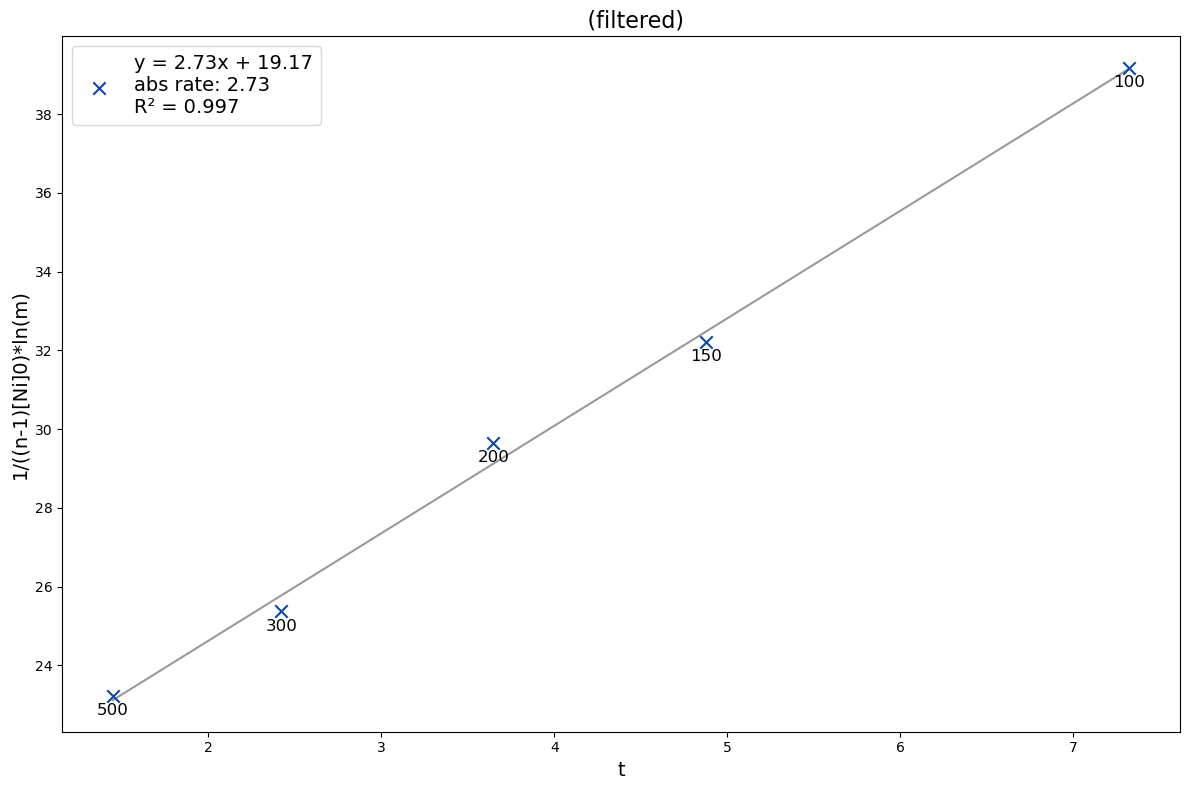

10 equiv  |  Slope: 2.7297  |  Intercept: 19.1676  |  R²: 0.9966


In [ ]:
exclude_scan_rates = [800]   # fill in after reviewing regression, e.g. [100, 200]

if exclude_scan_rates:
    print(f'=== EXCLUDING: {exclude_scan_rates} ===')
    regressionPlot(df_reg, outDir, nequiv,
                   ligname=ligname, substrate_name=substrate_name,
                   exclude=exclude_scan_rates,
                   title_suffix='(filtered)',
                   savename=f'{ligname}_cycle{cycle_to_plot}_filtered',
                   save_plot=save_plot)
else:
    print('No scan rates excluded. Fill in exclude_scan_rates in the config cell and rerun.')


## ── 5. OPTIONAL: manually corrected peaks ────────────────────────────────
If auto-detection got peaks wrong, save a corrected Excel as e.g. `cycle 2_modified.xlsx` and run this cell.

In [ ]:
from math import log

name_of_updated_excel = 'cycle 2_modified.xlsx'
nequiv_manual         = 50

excel_path = os.path.join(outDir, name_of_updated_excel)
df_m       = pd.read_excel(excel_path)
out_rows   = []

for _, row in df_m.iterrows():
    name    = row['name']
    Vswitch = row['Vswitch']
    RpeakC  = row['ipa']
    FpeakC  = row['ipc']
    RpeakV  = row['Epa']
    FpeakV  = row['Epc']
    sr      = row['scan rate']
    eq1 = RpeakC / FpeakC
    eq2 = (1 / nequiv_manual) + (((nequiv_manual - 1) / nequiv_manual) / eq1)
    eq4 = ((RpeakV - Vswitch) + (FpeakV - Vswitch)) / (sr / 1000)
    eq5 = (1 / ((nequiv_manual - 1) * 0.001)) * log(eq2)
    out_rows.append([name, eq4, eq5, sr, RpeakV, FpeakV, RpeakC, FpeakC, eq1, eq2, 0, Vswitch])

out_df = pd.DataFrame(out_rows, columns=[
    'name', 't', '1/((n-1)[Ni]0)*ln(m)', 'scan rate',
    'Epa', 'Epc', 'ipa', 'ipc',
    'ia/ic', 'm=1/nx(n-1)/n/(ia/ic)', '1/.001*(ia/ic)-1/.001', 'Vswitch'
])
out_df.to_excel(os.path.join(outDir, 'manually_updated_cycle.xlsx'), index=False)
display(out_df)

regressionPlot(out_df, outDir, nequiv_manual,
               ligname=ligname, substrate_name=substrate_name,
               exclude=[], title_suffix='(manual, all data)',
               savename=f'{ligname}_manual_all', save_plot=save_plot)

if exclude_scan_rates:
    regressionPlot(out_df, outDir, nequiv_manual,
                   ligname=ligname, substrate_name=substrate_name,
                   exclude=exclude_scan_rates,
                   title_suffix='(manual, filtered)',
                   savename=f'{ligname}_manual_filtered', save_plot=save_plot)
